In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, RocCurveDisplay,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, average_precision_score
)


pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style("whitegrid")

In [7]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl (36.7 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\gruni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Чтение данных

In [2]:
file_path = "ПЗ1.Метрики.xlsx"

# Лист с бинарной классификацией (sheet_index_num = 1)
df_clf = pd.read_excel(file_path, sheet_name="Binary Classification")

# Лист с регрессией (sheet_index_num = 2)
df_reg = pd.read_excel(file_path, sheet_name="Regression")

print("Classification shape:", df_clf.shape)
print("Regression shape:", df_reg.shape)
display(df_clf.head(10))
display(df_reg.head(10))

Classification shape: (5200, 6)
Regression shape: (5200, 4)


,model,part,Y_true,Y_pred_proba_1,Y_pred_proba_0,Y_pred
0,GradientBoosting,train,0,0.9700,0.0300,1
1,DecisionTree,train,0,0.4200,0.5800,0
2,DecisionTree,test,1,0.7600,0.2400,1
3,GradientBoosting,train,0,0.7600,0.2400,1
4,DecisionTree,train,0,0.7000,0.3000,1
5,DecisionTree,train,0,0.8100,0.1900,1
6,DecisionTree,test,1,0.8900,0.1100,1
7,DecisionTree,train,1,0.5400,0.4600,1
8,GradientBoosting,test,1,0.7000,0.3000,1
9,DecisionTree,train,0,0.6100,0.3900,1


,model,part,Y_true,Y_pred
0,Polynominal Reg,test,597,585
1,LinReg,test,1814,1845
2,LinReg,test,1339,1375
3,LinReg,test,673,690
4,LinReg,test,1912,1952
5,Polynominal Reg,train,437,468
6,LinReg,train,504,486
7,Polynominal Reg,train,475,473
8,LinReg,test,1919,1956
9,LinReg,test,1932,1915


In [10]:
pip install openpyxl fastexcel

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached fastexcel-0.21.0-cp310-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached fastexcel-0.21.0-cp310-abi3-win_amd64.whl (3.3 MB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\gruni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Функции расчёта метрик

In [3]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


def classification_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1-score":  f1_score(y_true, y_pred, zero_division=0),
        "AUC ROC":   roc_auc_score(y_true, y_proba),
        "AUC PR":    average_precision_score(y_true, y_proba),
    }

### Регрессия

In [4]:
# Создаём пустой список, в который будем складывать по одному словарю
# с метриками для каждой пары (model, part).
# Это стандартный паттерн «accumulate → DataFrame», он проще и быстрее,
# чем добавлять строки в DataFrame через .loc или pd.concat в цикле.
rows = []

# df_reg.groupby(["model", "part"]) разбивает датафрейм на группы
# по уникальным комбинациям значений в колонках "model" и "part".
# На каждой итерации:
#   (model, part) — кортеж с ключом группы (например, ("LinReg", "train"))
#   group         — под-DataFrame, содержащий только строки этой группы.
# В нашем случае получится 4 итерации: LinReg/train, LinReg/test,
# Polynominal Reg/train, Polynominal Reg/test.
for (model, part), group in df_reg.groupby(["model", "part"]):

    # Вызываем вспомогательную функцию regression_metrics(),
    # передавая ей:
    #   group["Y_true"].values — истинные значения (numpy-массив),
    #   group["Y_pred"].values — предсказанные значения (numpy-массив).
    # Функция возвращает словарь вида:
    #   {"MAE": ..., "MSE": ..., "RMSE": ..., "R2": ...}
    # Использование .values гарантирует, что sklearn получит чистый
    # numpy-массив без индексов pandas (иначе возможны неожиданные
    # выравнивания по индексу).
    m = regression_metrics(group["Y_true"].values, group["Y_pred"].values)

    # Добавляем в словарь с метриками информацию о том,
    # к какой модели и какой выборке относятся эти числа.
    # Это нужно, чтобы потом можно было фильтровать и сортировать
    # итоговую таблицу по этим колонкам.
    m["model"] = model
    m["part"]  = part

    # Кладём готовый словарь в общий список.
    # К концу цикла rows — это список из 4 словарей,
    # каждый из которых содержит 6 ключей:
    # model, part, MAE, MSE, RMSE, R2.
    rows.append(m)

# Преобразуем список словарей в DataFrame.
# Каждый ключ словаря становится колонкой, каждый словарь — строкой.
# Явное указание списка колонок [["model", "part", "MAE", "MSE", "RMSE", "R2"]]
# фиксирует их порядок и одновременно отбрасывает лишние ключи,
# если regression_metrics() вдруг начнёт возвращать что-то ещё.
reg_results = pd.DataFrame(rows)[["model", "part", "MAE", "MSE", "RMSE", "R2"]]

# Сортируем строки сначала по модели, потом по выборке —
# так таблица читается предсказуемо: сначала все train/test для
# одной модели, затем для другой.
# reset_index(drop=True) сбрасывает старый индекс (0..3 в порядке
# появления групп) и создаёт новый — уже в порядке сортировки.
# drop=True нужен, чтобы старый индекс не превратился в лишнюю колонку.
reg_results = reg_results.sort_values(["model", "part"]).reset_index(drop=True)

# Выводим итоговую таблицу в ячейке Jupyter
# (последнее выражение в ячейке отображается автоматически).
reg_results

,model,part,MAE,MSE,RMSE,R2
0,LinReg,test,16.9925,416.4279,20.4066,0.9983
1,LinReg,train,16.8251,405.3586,20.1335,0.9984
2,Polynominal Reg,test,16.5620,402.9623,20.0739,0.9983
3,Polynominal Reg,train,17.0380,417.0896,20.4228,0.9982


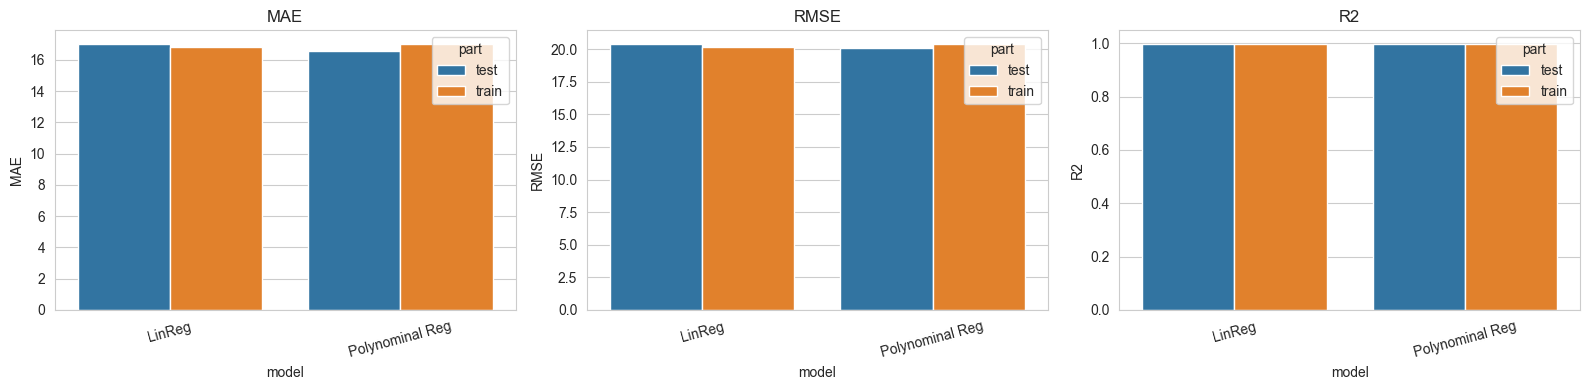

In [48]:
# Список метрик, которые будем рисовать на отдельных subplot'ах.
# Порядок в списке = порядок графиков слева направо.
# MAE и RMSE — «чем меньше, тем лучше», R2 — «чем ближе к 1, тем лучше»,
# поэтому визуально их удобно смотреть рядом, помня про разный смысл.
metrics = ["MAE", "RMSE", "R2"]

# Создаём фигуру с горизонтальным рядом subplot'ов.
# fig — объект Figure (всё «полотно»), axes — массив из len(metrics) осей.
# 1 строка, len(metrics)=3 столбца, общий размер 16×4 дюйма
# (широкий, чтобы три графика не сжимались).
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))

# zip(axes, metrics) идёт параллельно по осям и по названиям метрик:
#   ax = axes[0], metric = "MAE"
#   ax = axes[1], metric = "RMSE"
#   ax = axes[2], metric = "R2"
# Так на каждом subplot'е рисуется ровно своя метрика.
for ax, metric in zip(axes, metrics):

    # Столбчатая диаграмма (barplot) средствами seaborn.
    # data=reg_results — исходный DataFrame с колонками:
    #     model, part, MAE, MSE, RMSE, R2
    # x="model"   — по оси X категории моделей (LinReg, Polynominal Reg).
    # y=metric    — высота столбца = значение текущей метрики
    #               (подставляется "MAE", затем "RMSE", затем "R2").
    # hue="part"  — цвет столбца определяется выборкой (train / test).
    #               Это даёт две группы столбцов на каждую модель
    #               и автоматически строит легенду train/test.
    # ax=ax       — рисовать именно на текущей оси, а не создавать новую.
    #
    # Важно: seaborn по умолчанию строит СРЕДНЕЕ значение по группе
    # и рисует 95%-й доверительный интервал (чёрная «усатая» планка).
    # В наших данных на каждую пару (model, part) приходится ровно
    # одна строка, поэтому среднее = само значение, а интервал
    # будет вырожденным (или seaborn его просто не покажет).
    # Если хочется отключить интервал явно — добавьте errorbar=None.
    sns.barplot(
        data=reg_results, x="model", y=metric, hue="part", ax=ax
    )

    # Заголовок над конкретным subplot'ом — имя метрики.
    # Так читателю сразу понятно, что на графике.
    ax.set_title(metric)

    # Подписи моделей по оси X могут быть длинными
    # («Polynominal Reg»), поэтому поворачиваем их на 15°,
    # чтобы они не наезжали друг на друга и не обрезались.
    ax.tick_params(axis='x', rotation=15)

# Автоматическая подгонка отступов между subplot'ами,
# чтобы заголовки, подписи осей и легенды не пересекались.
# Вызывать до plt.show() — иначе эффекта не увидим.
plt.tight_layout()

# Показываем фигуру в ячейке Jupyter.
# В отдельном скрипте вместо этого обычно plt.savefig(...)
plt.show()

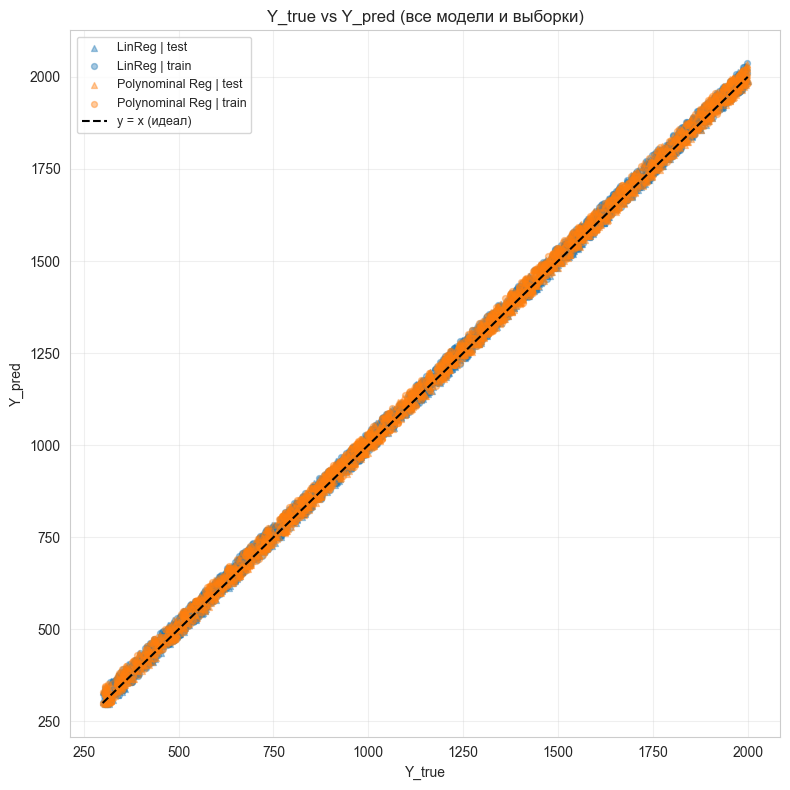

In [41]:
plt.figure(figsize=(8, 8))

markers = {"train": "o", "test": "^"}
colors = {"LinReg": "tab:blue", "Polynominal Reg": "tab:orange"}

for (model, part), group in df_reg.groupby(["model", "part"]):
    plt.scatter(
        group["Y_true"], group["Y_pred"],
        alpha=0.4, s=18,
        marker=markers[part],
        color=colors[model],
        label=f"{model} | {part}"
    )

lims = [df_reg["Y_true"].min(), df_reg["Y_true"].max()]
plt.plot(lims, lims, "k--", lw=1.5, label="y = x (идеал)")

plt.xlabel("Y_true")
plt.ylabel("Y_pred")
plt.title("Y_true vs Y_pred (все модели и выборки)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Классификация

In [42]:
clf_rows = []
clf_curves = {}     # для хранения ROC-кривых
cm_dict = {}        # для матриц ошибок

for (model, part), group in df_clf.groupby(["model", "part"]):
    y_true = group["Y_true"].values
    y_pred = group["Y_pred"].values
    # вероятность класса 1 — колонка Y_pred_proba_1
    y_proba = group["Y_pred_proba_1"].values

    m = classification_metrics(y_true, y_pred, y_proba)
    m["model"] = model
    m["part"] = part
    clf_rows.append(m)

    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    clf_curves[(model, part)] = (fpr, tpr, auc(fpr, tpr))

    # Confusion Matrix
    cm_dict[(model, part)] = confusion_matrix(y_true, y_pred)

clf_results = pd.DataFrame(clf_rows)[
    ["model", "part", "Accuracy", "Precision", "Recall", "F1-score", "AUC ROC", "AUC PR"]
].sort_values(["model", "part"]).reset_index(drop=True)

clf_results

,model,part,Accuracy,Precision,Recall,F1-score,AUC ROC,AUC PR
0,DecisionTree,test,0.5151,0.5347,0.5233,0.5289,0.5168,0.5342
1,DecisionTree,train,0.4957,0.5087,0.4939,0.5012,0.4832,0.4944
2,GradientBoosting,test,0.4715,0.4777,0.4711,0.4744,0.4727,0.4879
3,GradientBoosting,train,0.4984,0.5265,0.4768,0.5004,0.5108,0.5431


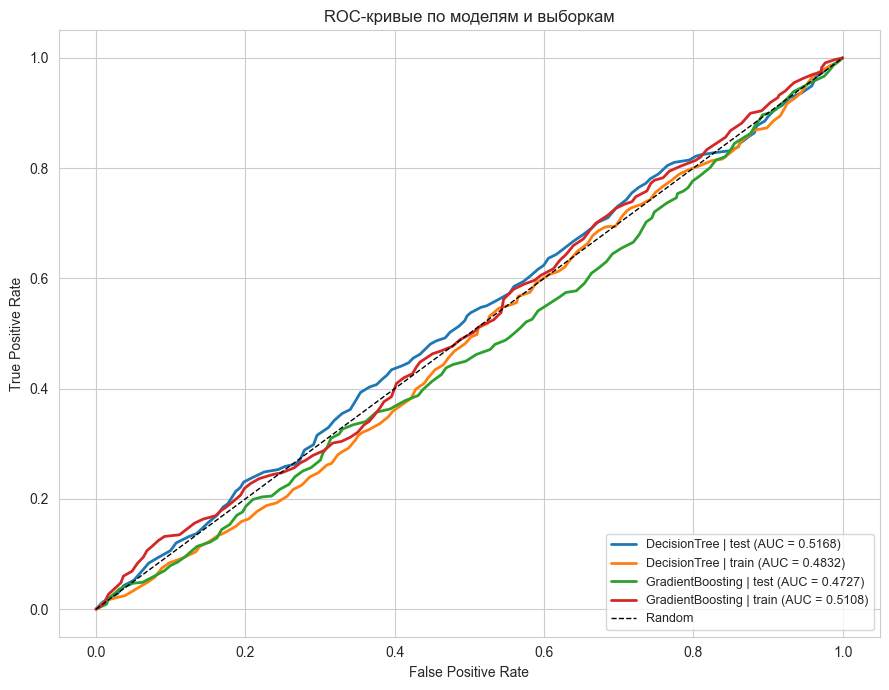

In [43]:
plt.figure(figsize=(9, 7))

for (model, part), (fpr, tpr, roc_auc) in clf_curves.items():
    plt.plot(fpr, tpr, lw=2, label=f"{model} | {part} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые по моделям и выборкам")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

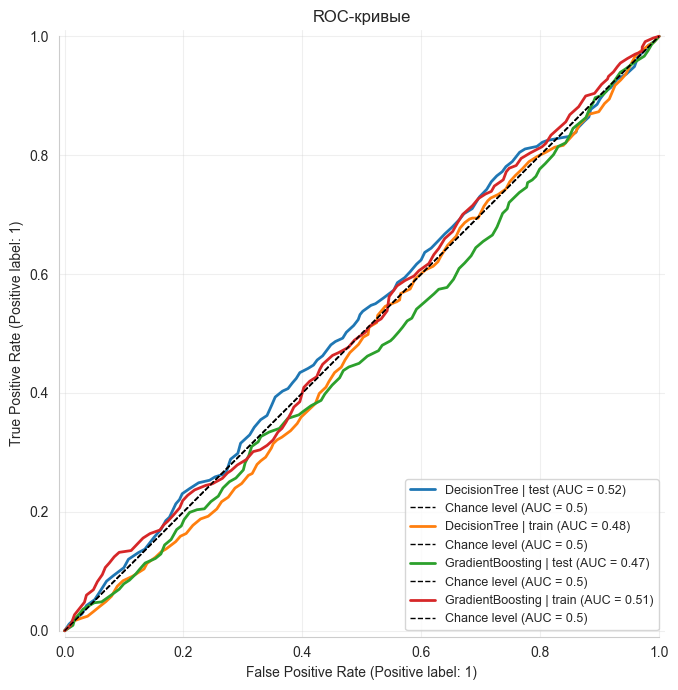

In [44]:
fig, ax = plt.subplots(figsize=(9, 7))

for model, part in pairs:
    group = df_clf[(df_clf["model"] == model) & (df_clf["part"] == part)]
    RocCurveDisplay.from_predictions(
        group["Y_true"].values,
        group["Y_pred_proba_1"].values,
        name=f"{model} | {part}",
        ax=ax,
        curve_kwargs={"lw": 2},
        plot_chance_level=True,                    # встроенная диагональ
        chance_level_kw={"linestyle": "--", "color": "k", "lw": 1},
        despine=True,
    )

ax.set_title("ROC-кривые")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

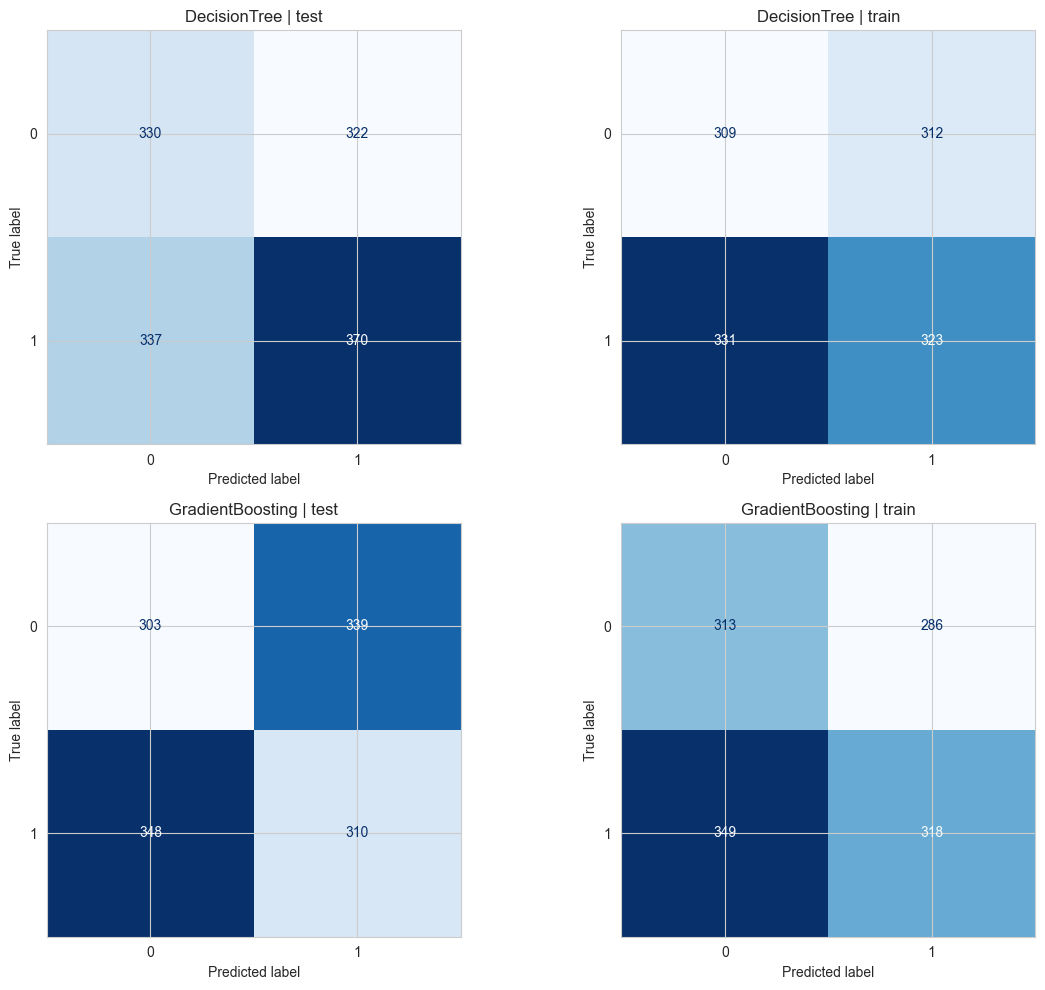

In [45]:
pairs = list(cm_dict.keys())
n = len(pairs)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, key in zip(axes, pairs):
    cm = cm_dict[key]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{key[0]} | {key[1]}")

for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()